<a href="https://colab.research.google.com/github/polinaklimenko820-spec/Global-Sales-Analysis/blob/main/global_sales_analysis_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Аналіз глобальних продажів: очищення, аналітика та бізнес-інсайти

**Portfolio project · Data Analytics · Python / pandas / seaborn**

Мета: перетворити три сирі таблиці продажів на відтворюваний аналітичний набір, оцінити якість даних, розрахувати ключові метрики та знайти практичні закономірності у товарах, географії, каналах і логістиці.

> Методологічна примітка: дохід, витрати та прибуток обчислюються як `Units Sold × Unit Price`, `Units Sold × Unit Cost` та їх різниця. Валюта в джерелі не позначена, тому суми подано в **умовних грошових одиницях (г.о.)**. 2017 рік неповний (дані лише до 22 липня), тому його не можна напряму порівнювати з повними роками.

In [ ]:
from pathlib import Path
import zipfile, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

LOCAL_FALLBACK = Path(r"C:\Users\polin\Downloads\dataset.zip")
candidates = [Path("/content/dataset.zip"), Path("dataset.zip"), LOCAL_FALLBACK]
zip_path = next((p for p in candidates if p.exists()), None)

if zip_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        zip_name = next(name for name in uploaded if name.lower().endswith(".zip"))
        zip_path = Path(zip_name)
    except Exception as exc:
        raise FileNotFoundError("Завантажте dataset.zip у поточну папку або в Colab.") from exc

extract_dir = Path("work_dataset")
if extract_dir.exists():
    shutil.rmtree(extract_dir)
extract_dir.mkdir()
with zipfile.ZipFile(zip_path) as zf:
    zf.extractall(extract_dir)

paths = {p.name.lower(): p for p in extract_dir.rglob("*.csv")}
required = {"events.csv", "products.csv", "countries.csv"}
missing_files = required - paths.keys()
assert not missing_files, f"В архіві не знайдено: {sorted(missing_files)}"
paths

Saving dataset.zip to dataset.zip


{'events.csv': PosixPath('work_dataset/13. Final project/events.csv'),
 'countries.csv': PosixPath('work_dataset/13. Final project/countries.csv'),
 'products.csv': PosixPath('work_dataset/13. Final project/products.csv')}

## 1. Data overview

### Структура і зміст таблиць

- **events.csv** — факти замовлень: ідентифікатор, дати, пріоритет, країна, товар, канал, кількість і ціни.
- **products.csv** — довідник категорій. Ключ `id` відповідає `Product ID` у продажах.
- **countries.csv** — довідник країн і регіонів. Ключ `alpha-3` відповідає `Country Code` у продажах.

Отже, модель даних має одну таблицю фактів і два довідники зі зв’язками **many-to-one**.

In [ ]:
NA_MARKERS = ["#N/A", "N/A", "NA", ""]
events_raw = pd.read_csv(paths["events.csv"], na_values=NA_MARKERS)
products_raw = pd.read_csv(paths["products.csv"], na_values=NA_MARKERS)
countries_raw = pd.read_csv(paths["countries.csv"], na_values=NA_MARKERS)

for name, frame in {"events": events_raw, "products": products_raw, "countries": countries_raw}.items():
    print(f"\n{name}: {frame.shape[0]:,} rows × {frame.shape[1]} columns")
    display(frame.head(3))


events: 1,330 rows × 10 columns


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.00,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,"1,993.00",205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,"4,693.00",668.27,502.54



products: 12 rows × 2 columns


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes



countries: 249 rows × 5 columns


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe


In [ ]:
column_dictionary = pd.DataFrame([
    ("events", "Order ID", "Унікальний ідентифікатор замовлення"),
    ("events", "Order Date", "Дата оформлення замовлення"),
    ("events", "Ship Date", "Дата відвантаження"),
    ("events", "Order Priority", "Пріоритет: C/H/M/L"),
    ("events", "Country Code", "Трилітерний код країни; FK → countries.alpha-3"),
    ("events", "Product ID", "Код товару; FK → products.id"),
    ("events", "Sales Channel", "Online або Offline"),
    ("events", "Units Sold", "Кількість проданих одиниць"),
    ("events", "Unit Price", "Ціна одиниці, г.о."),
    ("events", "Unit Cost", "Собівартість одиниці, г.о."),
    ("products", "id", "Унікальний код товару"),
    ("products", "item_type", "Категорія товару"),
    ("countries", "name", "Назва країни"),
    ("countries", "alpha-2", "Дволітерний код країни"),
    ("countries", "alpha-3", "Трилітерний код країни"),
    ("countries", "region", "Регіон світу"),
    ("countries", "sub-region", "Субрегіон"),
], columns=["table", "column", "description"])
display(column_dictionary)

,table,column,description
0,events,Order ID,Унікальний ідентифікатор замовлення
1,events,Order Date,Дата оформлення замовлення
2,events,Ship Date,Дата відвантаження
3,events,Order Priority,Пріоритет: C/H/M/L
4,events,Country Code,Трилітерний код країни; FK → countries.alpha-3
5,events,Product ID,Код товару; FK → products.id
6,events,Sales Channel,Online або Offline
7,events,Units Sold,Кількість проданих одиниць
8,events,Unit Price,"Ціна одиниці, г.о."
9,events,Unit Cost,"Собівартість одиниці, г.о."


## 2. Data cleaning і контроль якості

In [ ]:
def quality_profile(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True),
    })

for name, frame in {"events": events_raw, "products": products_raw, "countries": countries_raw}.items():
    display(Markdown(f"### {name}"))
    display(quality_profile(frame))
    print("Exact duplicate rows:", frame.duplicated().sum())

### events

,dtype,missing,missing_%,unique
Order ID,int64,0,0.00,1330
Order Date,object,0,0.00,1049
Ship Date,object,0,0.00,1070
Order Priority,object,0,0.00,6
Country Code,object,82,6.17,45
Product ID,int64,0,0.00,12
Sales Channel,object,0,0.00,3
Units Sold,float64,2,0.15,1239
Unit Price,float64,0,0.00,12
Unit Cost,float64,0,0.00,12


Exact duplicate rows: 0


### products

,dtype,missing,missing_%,unique
id,int64,0,0.00,12
item_type,object,0,0.00,12


Exact duplicate rows: 0


### countries

,dtype,missing,missing_%,unique
name,object,0,0.00,249
alpha-2,object,1,0.40,248
alpha-3,object,0,0.00,249
region,object,1,0.40,5
sub-region,object,1,0.40,17


Exact duplicate rows: 0


In [ ]:
events = events_raw.copy()
events.columns = (events.columns.str.strip().str.lower()
                  .str.replace(r"[^a-z0-9]+", "_", regex=True).str.strip("_"))
products = products_raw.rename(columns={"id": "product_id", "item_type": "category"}).copy()
countries = countries_raw.rename(columns={"name": "country", "alpha-3": "country_code",
                                          "sub-region": "sub_region"}).copy()

# Прибираємо невидимі пробіли; нормалізуємо регістр відомих категоріальних полів.
for frame in (events, products, countries):
    for col in frame.select_dtypes(include=["object", "string"]):
        frame[col] = frame[col].astype("string").str.strip()
events["sales_channel"] = events["sales_channel"].str.title()
events["order_priority"] = events["order_priority"].str.upper()

# Явне перетворення типів.
events["order_date"] = pd.to_datetime(events["order_date"], format="%m/%d/%Y", errors="coerce")
events["ship_date"] = pd.to_datetime(events["ship_date"], format="%m/%d/%Y", errors="coerce")
for col in ["order_id", "product_id", "units_sold", "unit_price", "unit_cost"]:
    events[col] = pd.to_numeric(events[col], errors="coerce")

# Дублікати перевіряємо після нормалізації тексту.
print("Duplicates after normalization:", events.duplicated().sum())
print("Duplicate Order IDs:", events["order_id"].duplicated().sum())
print("Channels:", events["sales_channel"].value_counts(dropna=False).to_dict())
print("Priorities:", events["order_priority"].value_counts(dropna=False).to_dict())

Duplicates after normalization: 0
Duplicate Order IDs: 0
Channels: {'Offline': 667, 'Online': 663}
Priorities: {'M': 354, 'H': 335, 'L': 334, 'C': 307}


### Рішення щодо пропусків

- `Country Code`: **не імпутуємо**, бо країну неможливо надійно відновити з інших полів. Замовлення залишаються в загальних KPI з категорією `Unknown`, але виключаються з рейтингів конкретних країн/регіонів.
- `Units Sold`: без кількості неможливо розрахувати дохід, витрати та прибуток. Два такі рядки вилучаються з аналітичного датафрейму; їхня частка лише 0,15%.
- Один пропуск `alpha-2/region/sub-region` у повному світовому довіднику не впливає на фактичні продажі.

In [ ]:
missing_summary = pd.DataFrame({
    "missing": events.isna().sum(),
    "share_%": (events.isna().mean() * 100).round(2)
}).query("missing > 0")
display(missing_summary)

events_clean = events.dropna(subset=["units_sold", "order_date", "ship_date", "product_id"]).copy()
events_clean["country_code"] = events_clean["country_code"].fillna("UNK")

# Перевірка покриття зовнішніх ключів до підстановки Unknown.
unmatched_products = set(events_clean["product_id"]) - set(products["product_id"])
unmatched_countries = set(events_clean.loc[events_clean.country_code.ne("UNK"), "country_code"]) - set(countries["country_code"])
print("Rows removed because Units Sold is missing:", len(events) - len(events_clean))
print("Unmatched product keys:", unmatched_products)
print("Unmatched non-null country keys:", unmatched_countries)

,missing,share_%
country_code,82,6.17
units_sold,2,0.15


Rows removed because Units Sold is missing: 2
Unmatched product keys: set()
Unmatched non-null country keys: set()


In [ ]:
# Контроль аномалій до об'єднання.
anomaly_checks = pd.Series({
    "ship_before_order": (events_clean.ship_date < events_clean.order_date).sum(),
    "units_non_positive": (events_clean.units_sold <= 0).sum(),
    "unit_price_negative": (events_clean.unit_price < 0).sum(),
    "unit_cost_negative": (events_clean.unit_cost < 0).sum(),
    "cost_above_price": (events_clean.unit_cost > events_clean.unit_price).sum(),
    "invalid_priority": (~events_clean.order_priority.isin(["C", "H", "M", "L"])).sum(),
    "invalid_channel": (~events_clean.sales_channel.isin(["Online", "Offline"])).sum(),
})
display(anomaly_checks.to_frame("count"))

,count
ship_before_order,0
units_non_positive,0
unit_price_negative,0
unit_cost_negative,0
cost_above_price,0
invalid_priority,0
invalid_channel,0


**Висновок якості.** Після нормалізації немає дублікатів, порушень ключів, від’ємних кількостей/цін, відвантажень до замовлення чи витрат вище ціни. Великі значення `Units Sold` не є статистичною помилкою: діапазон 2–9 999 виглядає як задуманий генератор великих оптових замовлень, тому їх не видаляємо.

## 3. Єдиний аналітичний датафрейм і feature engineering

In [ ]:
countries_for_join = countries[["country_code", "country", "region", "sub_region"]]
df = (events_clean
      .merge(products, on="product_id", how="left", validate="many_to_one")
      .merge(countries_for_join, on="country_code", how="left", validate="many_to_one"))

df[["country", "region", "sub_region"]] = df[["country", "region", "sub_region"]].fillna("Unknown")
df["revenue"] = df["units_sold"] * df["unit_price"]
df["cost"] = df["units_sold"] * df["unit_cost"]
df["profit"] = df["revenue"] - df["cost"]
df["profit_margin"] = df["profit"] / df["revenue"]
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()
df["month_num"] = df["order_date"].dt.month
df["weekday"] = df["order_date"].dt.day_name()

print("Final shape:", df.shape)
print("Date range:", df.order_date.min().date(), "—", df.order_date.max().date())
display(df.head())

Final shape: (1328, 23)
Date range: 2010-01-01 — 2017-07-23


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,country,region,sub_region,revenue,cost,profit,profit_margin,shipping_days,year,month,month_num,weekday
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.00,205.70,117.11,Cereal,Norway,Europe,Northern Europe,"133,705.00","76,121.50","57,583.50",0.43,10,2014,2014-10-01,10,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,"1,993.00",205.70,117.11,Cereal,Serbia,Europe,Southern Europe,"409,960.10","233,400.23","176,559.87",0.43,0,2016,2016-08-01,8,Thursday
2,101025998,2014-07-18,2014-08-11,M,UNK,7940,Online,"4,693.00",668.27,502.54,Household,Unknown,Unknown,Unknown,"3,136,191.11","2,358,420.22","777,770.89",0.25,24,2014,2014-07-01,7,Friday
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,"1,171.00",109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,"127,966.88","41,968.64","85,998.24",0.67,31,2017,2017-05-01,5,Saturday
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,"7,648.00",47.45,31.79,Beverages,Serbia,Europe,Southern Europe,"362,897.60","243,129.92","119,767.68",0.33,38,2012,2012-08-01,8,Saturday


## 4. KPI компанії

,value
Orders,"1,328.00"
Units sold,"6,576,524.00"
"Revenue, cu","1,702,129,408.21"
"Cost, cu","1,200,694,949.21"
"Profit, cu","501,434,459.00"
Profit margin,0.29
"Average order revenue, cu","1,281,723.95"
Median shipping days,25.00
Countries (known),45.00
Categories,12.00


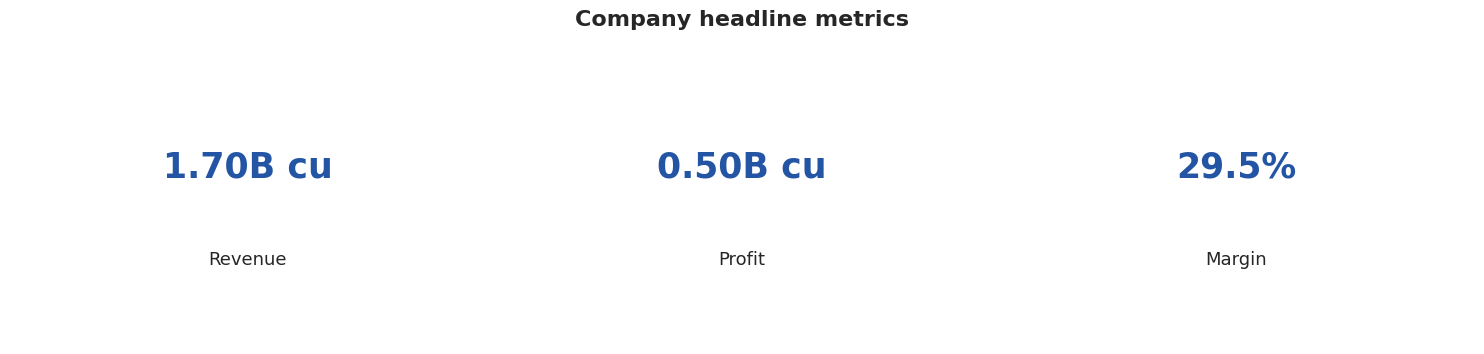

In [ ]:
kpis = pd.Series({
    "Orders": df.order_id.nunique(),
    "Units sold": df.units_sold.sum(),
    "Revenue, cu": df.revenue.sum(),
    "Cost, cu": df.cost.sum(),
    "Profit, cu": df.profit.sum(),
    "Profit margin": df.profit.sum() / df.revenue.sum(),
    "Average order revenue, cu": df.groupby("order_id").revenue.sum().mean(),
    "Median shipping days": df.shipping_days.median(),
    "Countries (known)": df.loc[df.country.ne("Unknown"), "country"].nunique(),
    "Categories": df.category.nunique(),
})
display(kpis.to_frame("value"))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
cards = [("Revenue", df.revenue.sum()), ("Profit", df.profit.sum()), ("Margin", df.profit.sum()/df.revenue.sum())]
for ax, (label, value) in zip(axes, cards):
    ax.axis("off")
    formatted = f"{value/1e9:.2f}B cu" if label != "Margin" else f"{value:.1%}"
    ax.text(.5, .62, formatted, ha="center", va="center", fontsize=25, weight="bold", color="#2455A4")
    ax.text(.5, .28, label, ha="center", fontsize=13)
plt.suptitle("Company headline metrics", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

## 5. Продажі за категоріями

Порівнюємо не лише дохід, а й прибуток та маржу: високий оборот не завжди означає найкращу економіку.

,orders,units,revenue,profit,avg_shipping_days,margin
category,,,,,,
Cosmetics,114,533291.000000,"233,154,825","92,723,306",25.9,39.8%
Office Supplies,123,617641.000000,"402,213,996","77,977,176",26.7,19.4%
Household,97,440249.000000,"294,205,199","72,962,467",23.9,24.8%
Baby Food,112,562706.000000,"143,647,588","53,940,997",26.3,37.6%
Clothes,105,591385.000000,"64,626,553","43,431,314",23.1,67.2%
Cereal,103,465685.000000,"95,791,404","41,255,034",27.2,43.1%
Vegetables,114,582544.000000,"89,746,729","36,776,003",23.5,41.0%
Meat,110,530380.000000,"223,762,018","30,337,736",25.9,13.6%
Snacks,103,490160.000000,"74,788,613","27,027,422",25.5,36.1%


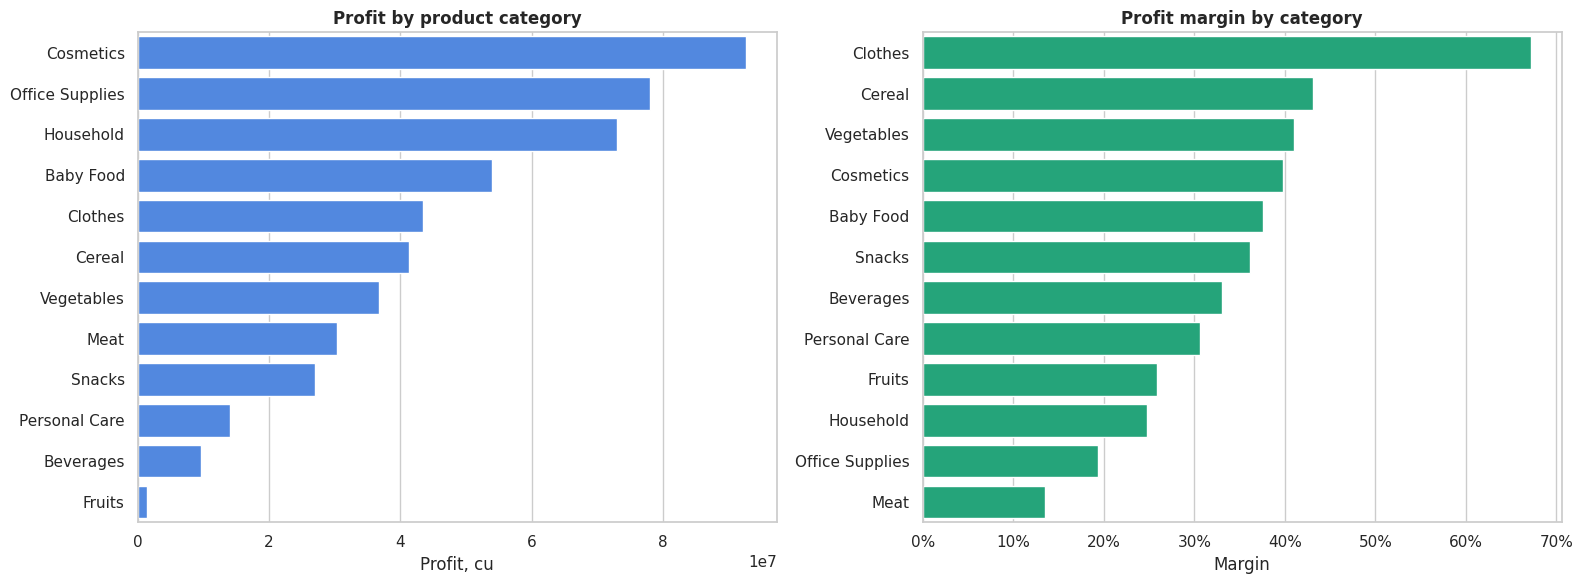

In [ ]:
category = (df.groupby("category")
            .agg(orders=("order_id", "nunique"), units=("units_sold", "sum"),
                 revenue=("revenue", "sum"), profit=("profit", "sum"),
                 avg_shipping_days=("shipping_days", "mean"))
            .assign(margin=lambda x: x.profit / x.revenue)
            .sort_values("profit", ascending=False))
display(category.style.format({"revenue":"{:,.0f}", "profit":"{:,.0f}", "margin":"{:.1%}", "avg_shipping_days":"{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=category.reset_index(), y="category", x="profit", ax=axes[0], color="#3B82F6")
axes[0].set(title="Profit by product category", xlabel="Profit, cu", ylabel="")
sns.barplot(data=category.sort_values("margin", ascending=False).reset_index(), y="category", x="margin", ax=axes[1], color="#10B981")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].set(title="Profit margin by category", xlabel="Margin", ylabel="")
plt.tight_layout(); plt.show()

**Інсайт.** Cosmetics дає найбільший абсолютний прибуток, Office Supplies — найбільший дохід, але значно нижчу маржу. Clothes має найвищу маржу (~67%), тому є кандидатом для масштабування, якщо попит і операційні обмеження це дозволяють. Meat генерує великий дохід, але маржа близько 14% — тут особливо важливі контроль собівартості й ціноутворення.

## 6. Географія: регіони та країни

,orders,revenue,profit,margin
region,,,,
Europe,1164,"1,505,652,874","448,556,782",29.8%
Asia,82,"93,330,887","25,152,253",26.9%


,orders,revenue,profit,avg_shipping_days,margin
country,,,,,
Andorra,40,"47,756,693","15,410,037",26.3,32.3%
Ukraine,33,"53,252,318","14,804,926",25.8,27.8%
Malta,32,"47,145,321","14,610,128",21.6,31.0%
San Marino,40,"47,883,708","13,792,993",21.7,28.8%
Hungary,25,"42,408,249","13,786,231",32.6,32.5%
Macedonia,32,"49,222,085","13,684,100",23.2,27.8%
Czech Republic,31,"53,543,932","13,635,594",25.2,25.5%
Russia,32,"46,051,660","13,267,683",27.4,28.8%
Bosnia and Herzegovina,33,"50,117,508","13,257,603",26.1,26.5%


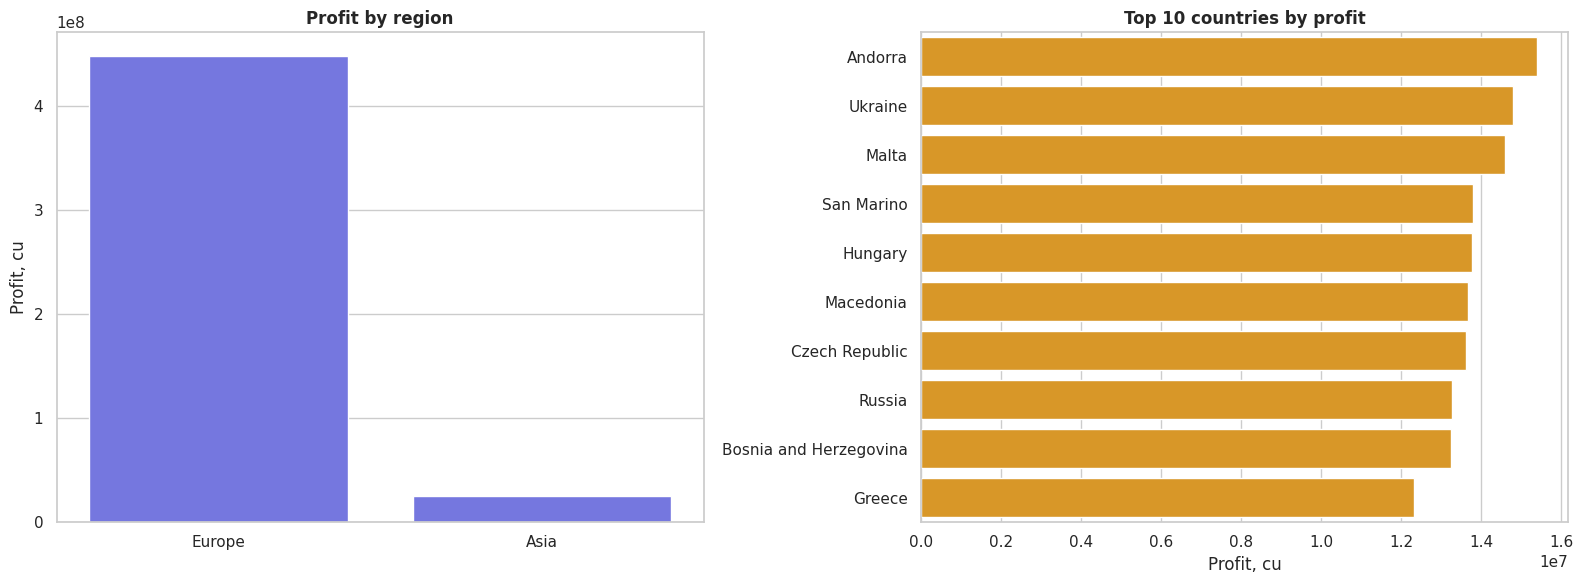

In [ ]:
geo = df[df.country.ne("Unknown")].copy()
region = (geo.groupby("region").agg(orders=("order_id","nunique"), revenue=("revenue","sum"), profit=("profit","sum"))
          .assign(margin=lambda x: x.profit/x.revenue).sort_values("profit", ascending=False))
country = (geo.groupby("country").agg(orders=("order_id","nunique"), revenue=("revenue","sum"), profit=("profit","sum"), avg_shipping_days=("shipping_days","mean"))
           .assign(margin=lambda x: x.profit/x.revenue).sort_values("profit", ascending=False))
display(region.style.format({"revenue":"{:,.0f}", "profit":"{:,.0f}", "margin":"{:.1%}"}))
display(country.head(10).style.format({"revenue":"{:,.0f}", "profit":"{:,.0f}", "margin":"{:.1%}", "avg_shipping_days":"{:.1f}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=region.reset_index(), x="region", y="profit", ax=axes[0], color="#6366F1")
axes[0].set(title="Profit by region", xlabel="", ylabel="Profit, cu")
sns.barplot(data=country.head(10).reset_index(), y="country", x="profit", ax=axes[1], color="#F59E0B")
axes[1].set(title="Top 10 countries by profit", xlabel="Profit, cu", ylabel="")
plt.tight_layout(); plt.show()

**Інсайт.** Відомі продажі сконцентровані в Європі; Азія представлена лише частково. Це властивість вибірки, а не доказ повного світового покриття. Найбільший прибуток серед країн має Andorra, далі — Ukraine і Malta. Для 82 замовлень географія невідома, тому їх не слід штучно розподіляти між країнами.

## 7. Онлайн проти офлайн

,orders,units,revenue,profit,avg_shipping_days,margin
sales_channel,,,,,,
Offline,665,3320363.000000,"871,760,624","253,466,519",25.1,29.1%
Online,663,3256161.000000,"830,368,784","247,967,940",24.5,29.9%


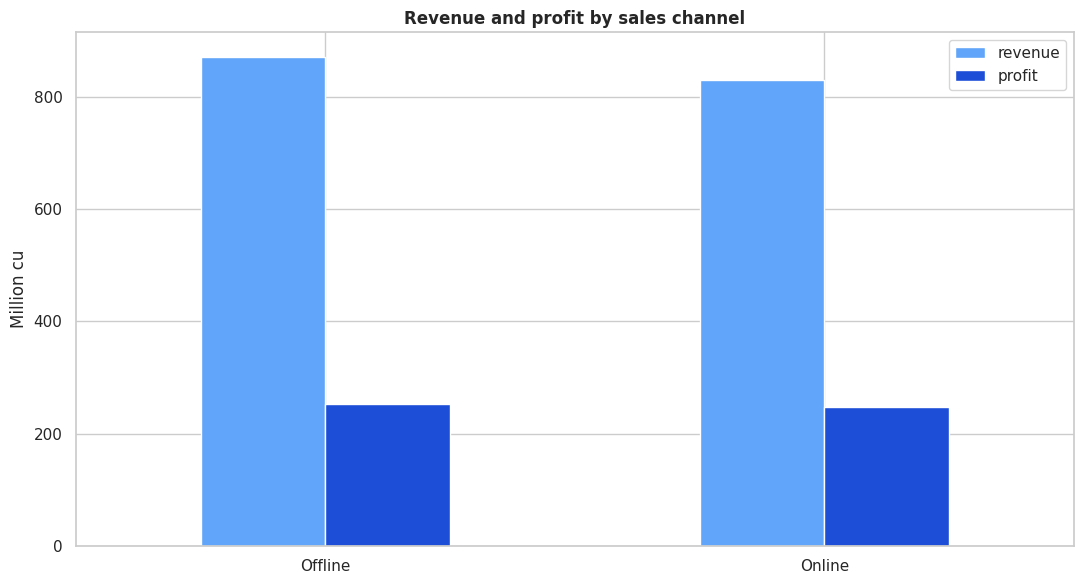

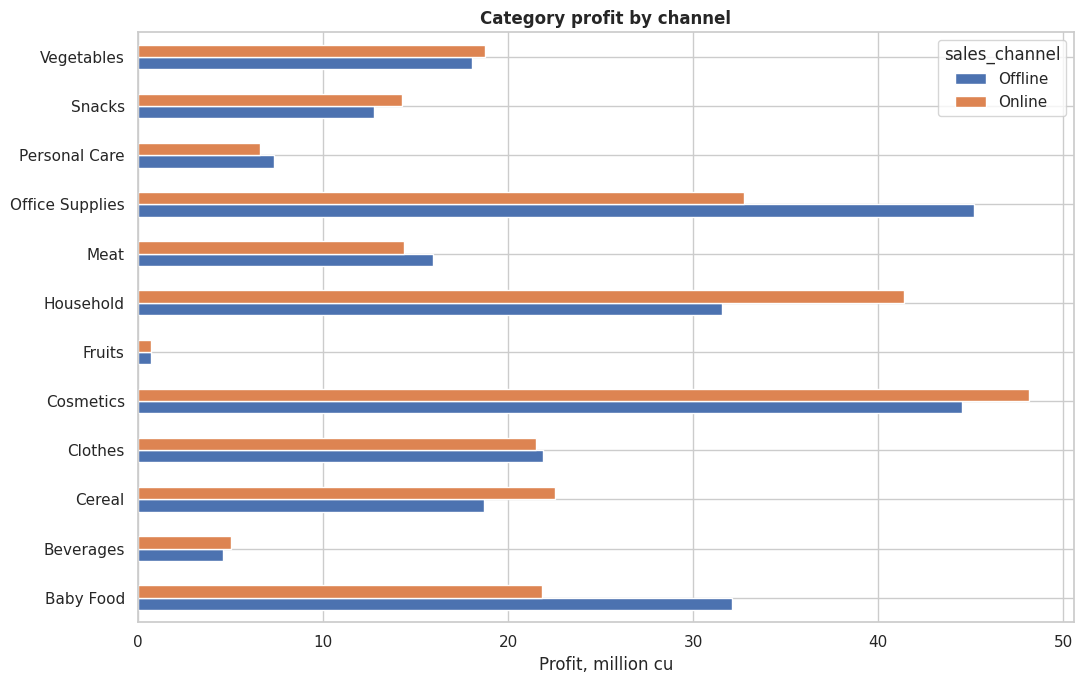

In [ ]:
channel = (df.groupby("sales_channel").agg(orders=("order_id","nunique"), units=("units_sold","sum"), revenue=("revenue","sum"), profit=("profit","sum"), avg_shipping_days=("shipping_days","mean"))
           .assign(margin=lambda x: x.profit/x.revenue))
display(channel.style.format({"revenue":"{:,.0f}", "profit":"{:,.0f}", "margin":"{:.1%}", "avg_shipping_days":"{:.1f}"}))

plot_ch = channel[["revenue", "profit"]].div(1e6)
plot_ch.plot(kind="bar", rot=0, color=["#60A5FA", "#1D4ED8"])
plt.title("Revenue and profit by sales channel")
plt.ylabel("Million cu"); plt.xlabel(""); plt.tight_layout(); plt.show()

mix = df.pivot_table(index="category", columns="sales_channel", values="profit", aggfunc="sum", fill_value=0)
mix.div(1e6).plot(kind="barh", figsize=(11, 7))
plt.title("Category profit by channel"); plt.xlabel("Profit, million cu"); plt.ylabel("")
plt.tight_layout(); plt.show()

**Інсайт.** Канали близькі за масштабом, тому рішення про перерозподіл бюджету варто приймати на рівні категорій, а не лише за загальним підсумком. Маржа категорії тут стала, бо ціна й собівартість у датасеті фіксовані для кожного товару.

## 8. Швидкість відвантаження

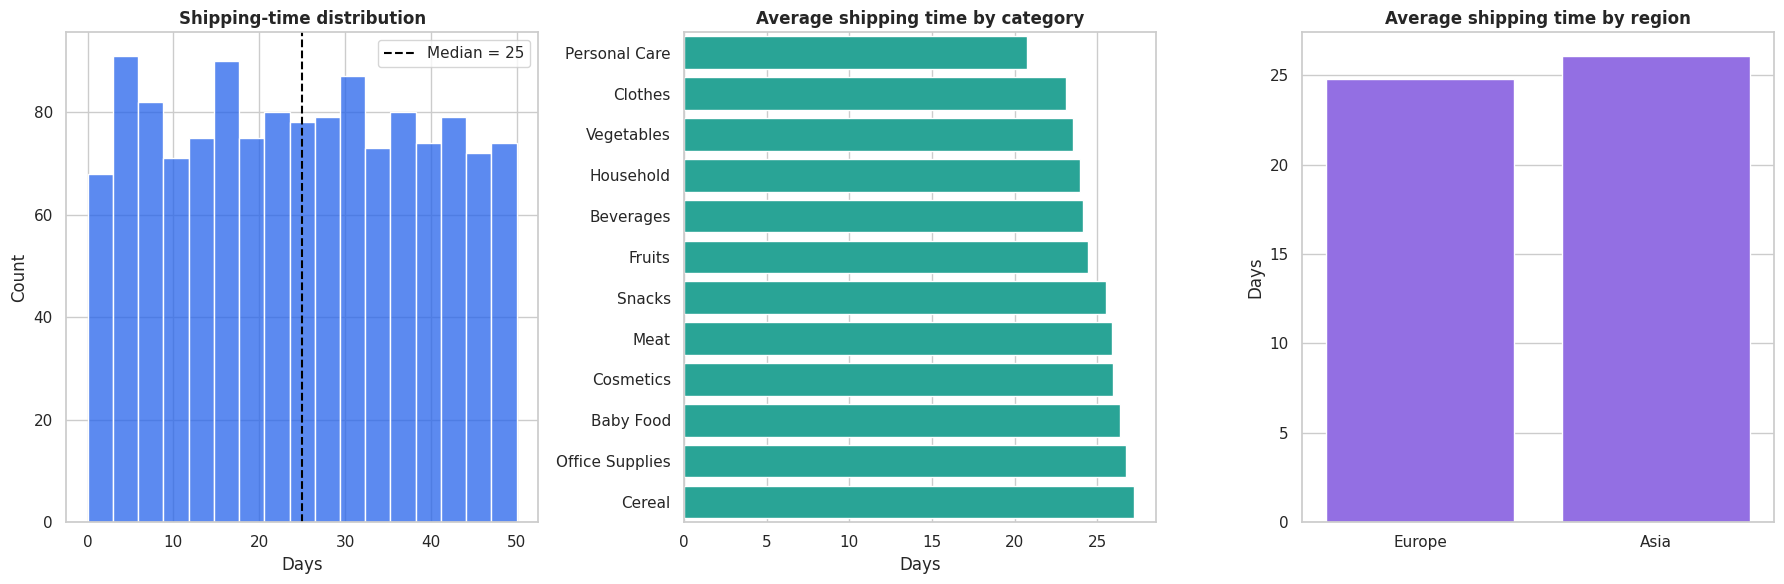

,count,mean,median
country,,,
Hungary,25,32.6,36.0
Georgia,23,29.7,32.0
Austria,28,28.5,29.0
Slovakia,30,28.5,32.0
Luxembourg,28,27.8,30.5
Lithuania,25,27.6,30.0
Poland,28,27.5,27.0
Russia,32,27.4,34.0
Monaco,13,26.8,33.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(df.shipping_days, bins=17, ax=axes[0], color="#2563EB")
axes[0].axvline(df.shipping_days.median(), color="black", ls="--", label=f"Median = {df.shipping_days.median():.0f}")
axes[0].legend(); axes[0].set(title="Shipping-time distribution", xlabel="Days")

ship_cat = df.groupby("category", as_index=False).shipping_days.mean().sort_values("shipping_days")
sns.barplot(data=ship_cat, y="category", x="shipping_days", ax=axes[1], color="#14B8A6")
axes[1].set(title="Average shipping time by category", xlabel="Days", ylabel="")

ship_reg = geo.groupby("region", as_index=False).shipping_days.mean().sort_values("shipping_days")
sns.barplot(data=ship_reg, x="region", y="shipping_days", ax=axes[2], color="#8B5CF6")
axes[2].set(title="Average shipping time by region", xlabel="", ylabel="Days")
plt.tight_layout(); plt.show()

ship_country = geo.groupby("country").shipping_days.agg(["count","mean","median"]).sort_values("mean", ascending=False)
display(ship_country.head(10).style.format({"mean":"{:.1f}", "median":"{:.1f}"}))

**Інсайт.** Медіана відвантаження — 25 днів, а значення розподілені майже по всьому діапазону 0–50 днів. Office Supplies і Cereal мають найдовший середній цикл серед категорій; Personal Care — найкоротший. Середні країни варто трактувати разом із кількістю замовлень, щоб не робити висновки з малих вибірок.

## 9. Чи залежить прибуток від часу відвантаження?

,orders,avg_profit,total_profit,avg_revenue
shipping_band,,,,
0–10,285,"345,661","98,513,324","1,095,644"
11–20,267,"364,998","97,454,341","1,293,047"
21–30,255,"371,288","94,678,477","1,261,052"
31–40,275,"414,792","114,067,665","1,415,068"
41–50,246,"393,173","96,720,653","1,357,380"


Pearson correlation (shipping days vs order profit): 0.060


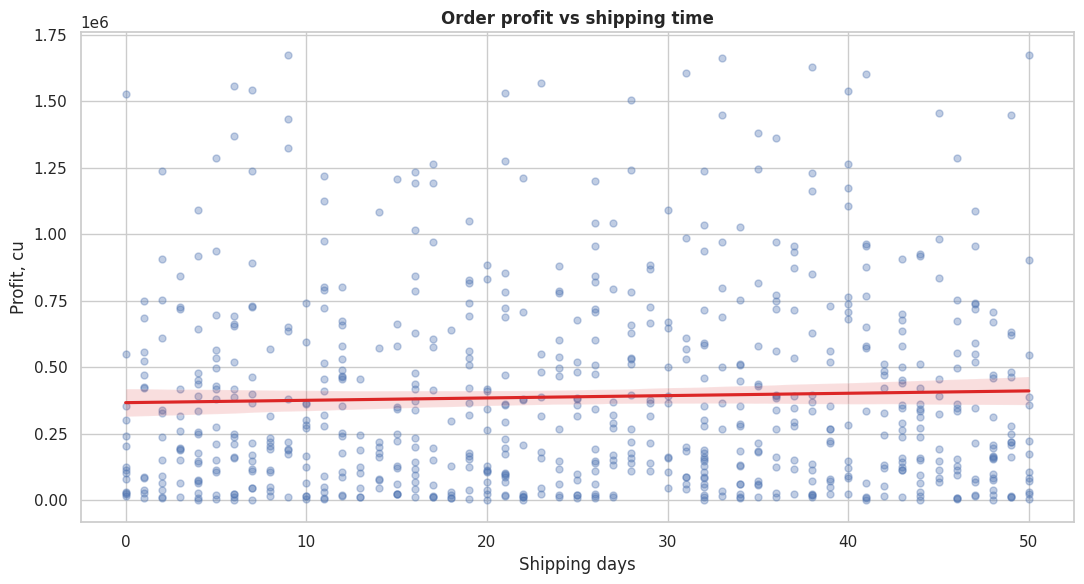

In [ ]:
shipping_corr = df[["shipping_days", "profit"]].corr(method="pearson").iloc[0, 1]
ship_bins = pd.cut(df.shipping_days, bins=[-1, 10, 20, 30, 40, 50], labels=["0–10", "11–20", "21–30", "31–40", "41–50"])
ship_profit = df.assign(shipping_band=ship_bins).groupby("shipping_band", observed=False).agg(
    orders=("order_id","nunique"), avg_profit=("profit","mean"), total_profit=("profit","sum"), avg_revenue=("revenue","mean"))
display(ship_profit.style.format({"avg_profit":"{:,.0f}", "total_profit":"{:,.0f}", "avg_revenue":"{:,.0f}"}))
print(f"Pearson correlation (shipping days vs order profit): {shipping_corr:.3f}")

sample = df.sample(min(700, len(df)), random_state=42)
sns.regplot(data=sample, x="shipping_days", y="profit", scatter_kws={"alpha":.35, "s":25}, line_kws={"color":"#DC2626"})
plt.title("Order profit vs shipping time")
plt.xlabel("Shipping days"); plt.ylabel("Profit, cu"); plt.tight_layout(); plt.show()

**Висновок.** Кореляція близька до нуля (~0,06): у цьому наборі немає практично значущої лінійної залежності між прибутком замовлення та часом відвантаження. Це не доводить, що швидкість доставки не впливає на повторні покупки або задоволеність — таких показників у даних немає.

## 10. Динаміка продажів у часі

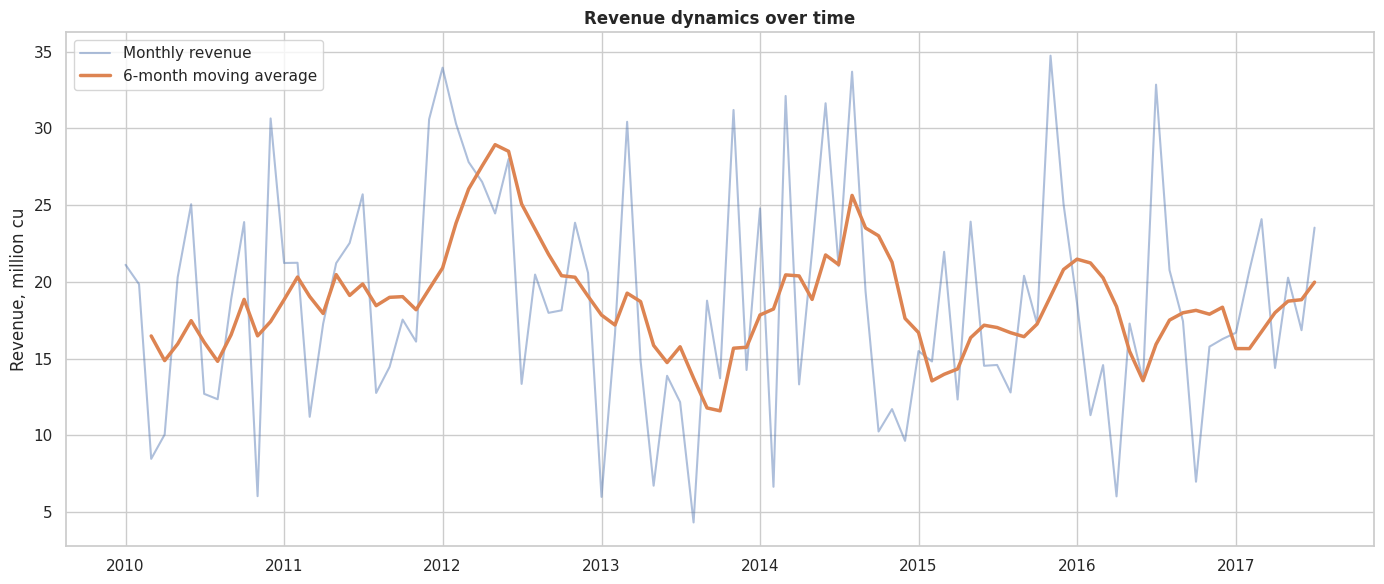

,orders,revenue,profit
year,,,
2010,166,"209,382,247","61,422,460"
2011,175,"231,937,557","69,044,660"
2012,202,"285,485,892","87,884,066"
2013,158,"182,962,359","53,387,995"
2014,186,"236,285,823","71,189,626"
2015,160,"227,954,099","61,734,040"
2016,175,"191,520,957","57,771,921"
2017,106,"136,600,474","38,999,691"


In [ ]:
monthly = df.groupby("month").agg(revenue=("revenue","sum"), profit=("profit","sum"), orders=("order_id","nunique")).reset_index()
monthly["revenue_ma_6"] = monthly.revenue.rolling(6, min_periods=3).mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly.month, monthly.revenue/1e6, alpha=.45, label="Monthly revenue")
plt.plot(monthly.month, monthly.revenue_ma_6/1e6, linewidth=2.5, label="6-month moving average")
plt.title("Revenue dynamics over time")
plt.ylabel("Revenue, million cu"); plt.xlabel(""); plt.legend(); plt.tight_layout(); plt.show()

yearly = df.groupby("year").agg(orders=("order_id","nunique"), revenue=("revenue","sum"), profit=("profit","sum"))
display(yearly.style.format({"revenue":"{:,.0f}", "profit":"{:,.0f}"}))

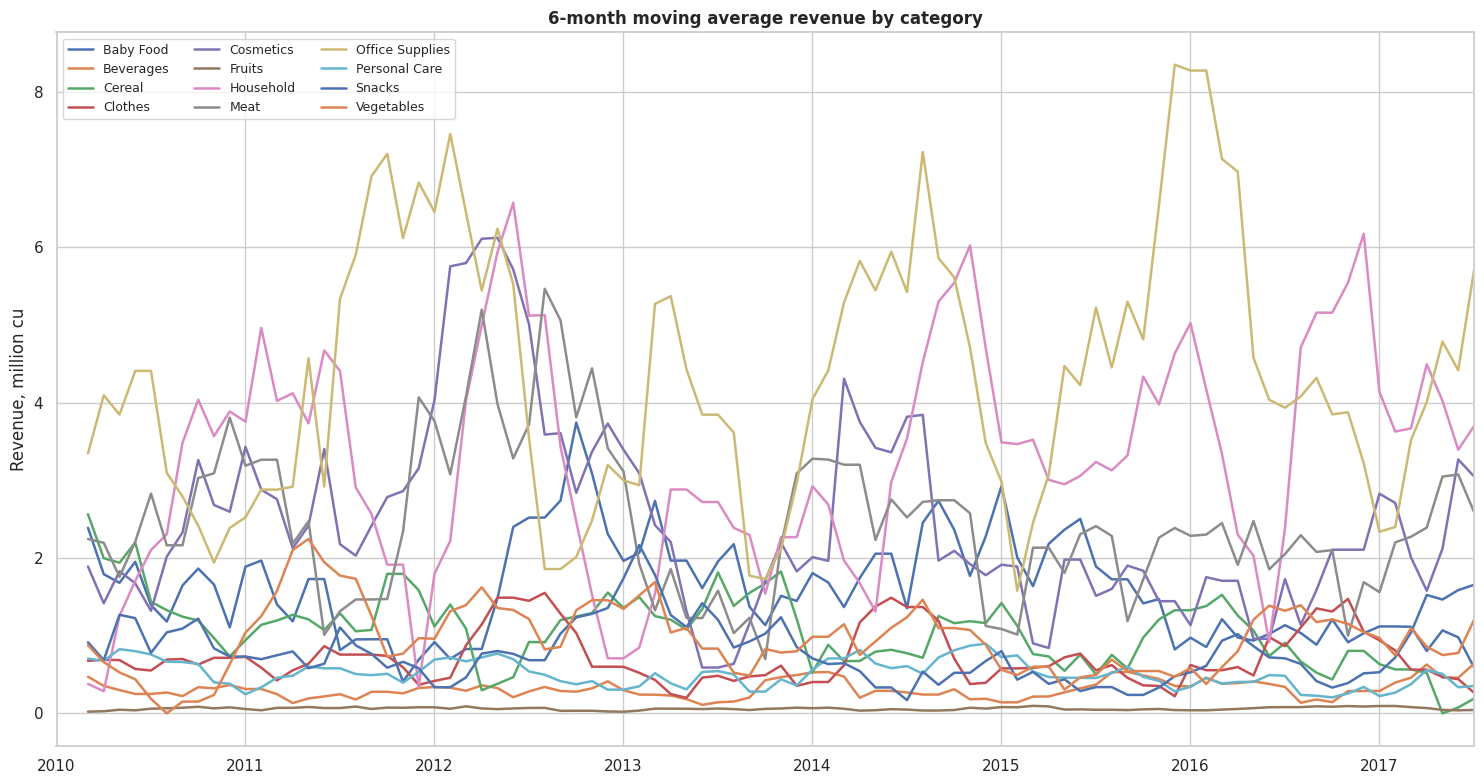

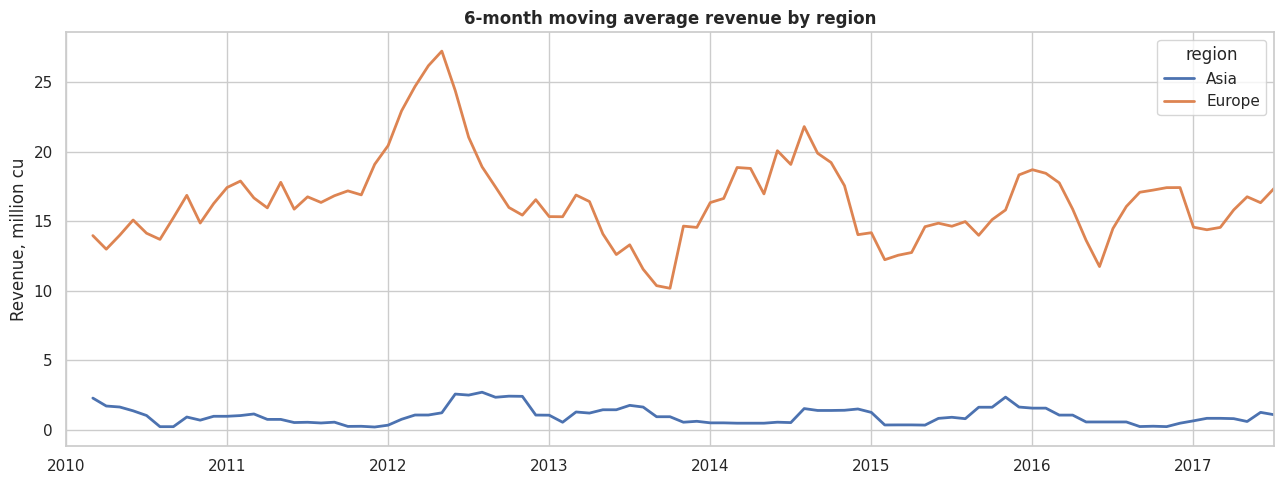

In [ ]:
cat_month = df.pivot_table(index="month", columns="category", values="revenue", aggfunc="sum", fill_value=0)
(cat_month.rolling(6, min_periods=3).mean()/1e6).plot(figsize=(15, 8), linewidth=1.8)
plt.title("6-month moving average revenue by category")
plt.ylabel("Revenue, million cu"); plt.xlabel(""); plt.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

region_month = geo.pivot_table(index="month", columns="region", values="revenue", aggfunc="sum", fill_value=0)
(region_month.rolling(6, min_periods=3).mean()/1e6).plot(figsize=(13, 5), linewidth=2)
plt.title("6-month moving average revenue by region")
plt.ylabel("Revenue, million cu"); plt.xlabel(""); plt.tight_layout(); plt.show()

**Інтерпретація.** Місячні ряди дуже волатильні, бо вибірка містить небагато великих оптових замовлень. Згладження допомагає бачити тенденції, але 2017 рік є неповним і не повинен використовуватися як доказ річного падіння. Категорії з високою ціною одиниці (Office Supplies, Household, Cosmetics, Meat) визначають більшу частину коливань виручки.

## 11. Дні тижня та сезонність

,orders,revenue,profit
weekday,,,
Monday,201,"275,468,475.80","75,790,330.12"
Tuesday,182,"213,523,894.55","65,637,400.07"
Wednesday,194,"261,215,696.73","72,323,843.38"
Thursday,167,"214,922,230.51","64,325,663.17"
Friday,176,"263,807,003.93","79,234,529.04"
Saturday,201,"233,641,145.43","71,435,860.49"
Sunday,207,"239,550,961.26","72,686,832.73"


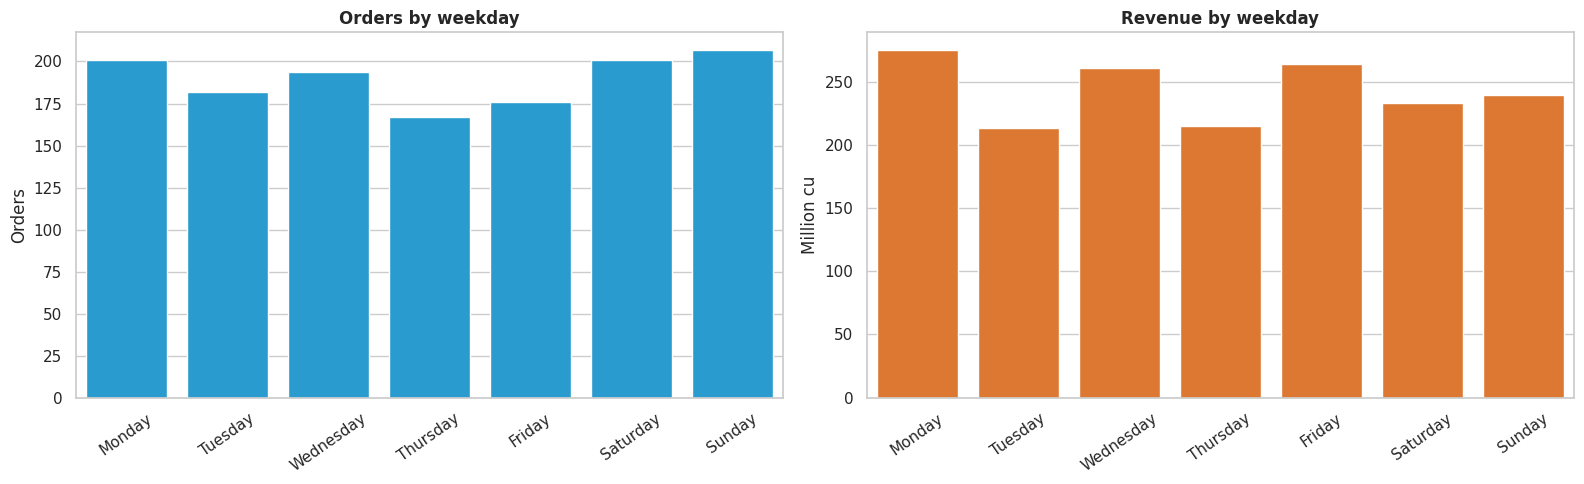

In [ ]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = df.groupby("weekday").agg(orders=("order_id","nunique"), revenue=("revenue","sum"), profit=("profit","sum")).reindex(weekday_order)
display(weekday)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=weekday.index, y=weekday.orders, ax=axes[0], color="#0EA5E9")
axes[0].tick_params(axis="x", rotation=35); axes[0].set(title="Orders by weekday", xlabel="", ylabel="Orders")
sns.barplot(x=weekday.index, y=weekday.revenue/1e6, ax=axes[1], color="#F97316")
axes[1].tick_params(axis="x", rotation=35); axes[1].set(title="Revenue by weekday", xlabel="", ylabel="Million cu")
plt.tight_layout(); plt.show()

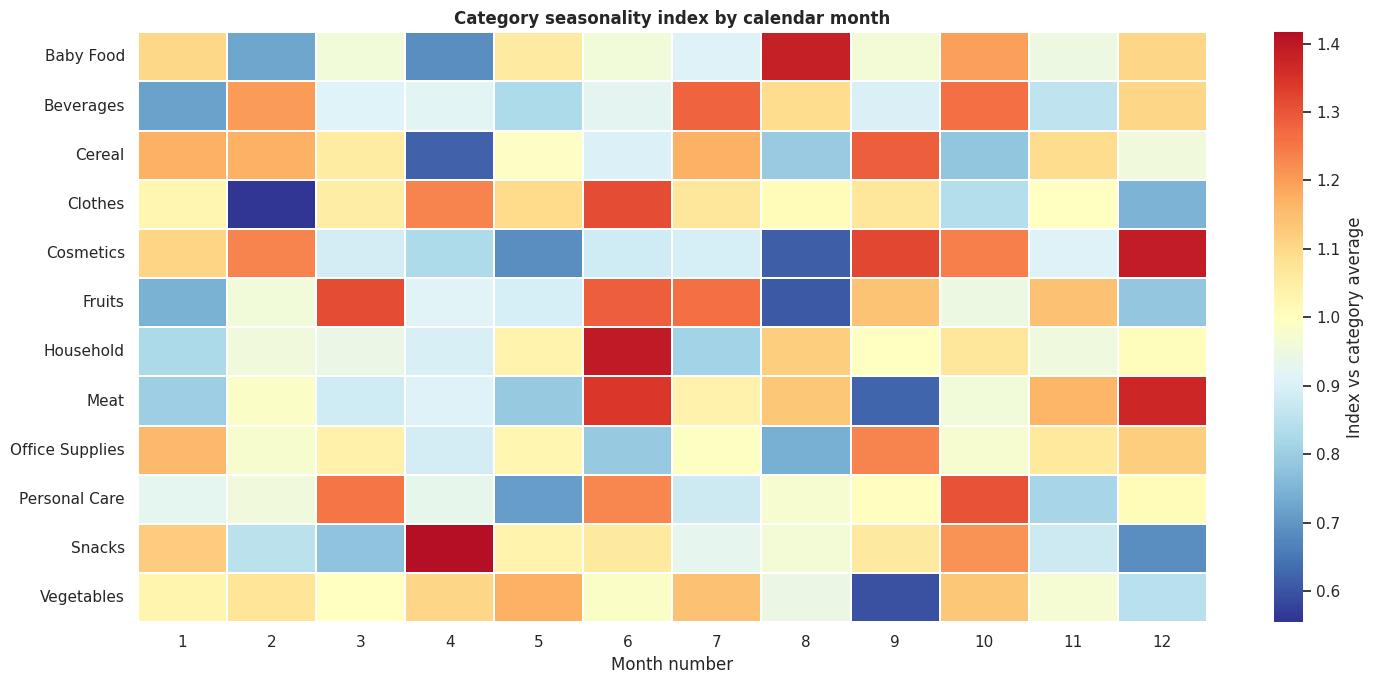

,max_minus_min_index
category,
Cosmetics,0.78
Clothes,0.76
Meat,0.75
Snacks,0.73
Fruits,0.70
Baby Food,0.70
Cereal,0.67
Personal Care,0.59
Household,0.58


In [ ]:
# Місячний сезонний профіль: середня виручка кожної категорії для відповідного місяця року.
seasonality = df.pivot_table(index="month_num", columns="category", values="revenue", aggfunc="mean")
normalized = seasonality.div(seasonality.mean(axis=0), axis=1)
plt.figure(figsize=(15, 7))
sns.heatmap(normalized.T, cmap="RdYlBu_r", center=1, linewidths=.3, cbar_kws={"label":"Index vs category average"})
plt.title("Category seasonality index by calendar month")
plt.xlabel("Month number"); plt.ylabel(""); plt.tight_layout(); plt.show()

# Простий діагностичний рейтинг сили сезонності; не статистичний тест.
seasonality_strength = (normalized.max() - normalized.min()).sort_values(ascending=False).to_frame("max_minus_min_index")
display(seasonality_strength)

**Висновок щодо сезонності.** День тижня описує операційний ритм, але сам по собі не визначає сезонність товару. Теплова карта за календарними місяцями показує локальні піки, однак на 7,5 року припадає лише близько 8 спостережень кожного місяця, а великі замовлення створюють шум. Тому категорії з високим `max_minus_min_index` можна вважати **кандидатами** на сезонність, але не доведеними сезонними товарами. Для підтвердження потрібні довший ряд, кількість клієнтів/замовлень і статистичний тест.

## 12. Підсумкові бізнес-висновки та рекомендації

1. **Прибуток концентрується у кількох категоріях.** Cosmetics — лідер абсолютного прибутку; Office Supplies і Household забезпечують великий оборот. Доцільно захищати наявність і постачання цих категорій.
2. **Clothes має винятково високу маржу.** Варто перевірити, чи можна збільшити обсяг без погіршення ціни, повернень і логістики. Натомість Meat має низьку маржу — пріоритетом є переговори щодо собівартості або перегляд ціни.
3. **Географічне покриття вибірки нерівномірне.** Європа домінує; 6,17% замовлень не мають країни. Перед географічними інвестиціями потрібно відновити обов’язкову валідацію `Country Code` у джерелі.
4. **Канал слід оптимізувати на рівні товару.** Онлайн і офлайн близькі за загальним масштабом, але категоріальний мікс різниться. Наступний крок — додати маркетингові витрати, комісії та повернення, щоб порівняти contribution margin.
5. **Логістичний цикл довгий, але не пояснює прибуток.** Медіана — 25 днів; кореляція з прибутком слабка. KPI доставки краще пов’язувати з SLA, задоволеністю і повторними покупками, яких у датасеті немає.
6. **Сезонність поки не доведена.** Помітні місячні піки можуть бути результатом великих разових замовлень. Для планування запасів варто перевірити стабільність патернів на детальніших транзакційних даних.

### Що додати в наступній ітерації

- валюта, клієнт, номер рядка замовлення, знижка, фактична доставка, повернення;
- маркетингові та логістичні витрати для повної unit economics;
- контроль якості при введенні: обов’язкова країна, єдиний регістр каналу, допустимі значення пріоритету;
- прогнозування лише після перевірки повноти часових періодів і сезонності.

## 13. Експорт очищених даних (опційно)

In [ ]:
# Розкоментуйте в Colab, якщо потрібен очищений CSV.
# df.to_csv("clean_global_sales.csv", index=False)
# from google.colab import files
# files.download("clean_global_sales.csv")

print(f"Analysis complete: {len(df):,} clean rows and {df.shape[1]} columns.")

Analysis complete: 1,328 clean rows and 23 columns.
